## Performance Impact of Block Reduction Sizes

This notebook benchmarks the performance of a grid computation using various block reduction sizes. The goal is to identify the optimal block size for this hardware configuration.

In this notebook, we apply the workflow to real magnetic data from the Paraná Basin.  
The dataset, provided by ANP, is available through the [CPRM/REATE portal](https://reate.cprm.gov.br/anp/TERRESTRE).

The data can be automatically downloaded within this notebook, where it is also preprocessed.  
As part of the preparation, the sampling rate is reduced from 100 Hz to 1 Hz  
(see `02-parana-basin-data-preparation.ipynb`).

In [ ]:
import os
import pygmt
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import bordado as bd
import boule as bl
import harmonica as hm
import verde as vd
import itertools
from scipy.interpolate import griddata

import spherical as sph

In [ ]:
def save_fit_results(model, filename="fit_results"):
    attrs = {}
    for key in ["residuals_", "dipole_moments_", "window_centers_", "source_coordinates_"]:
        if hasattr(model, key):
            attrs[key] = getattr(model, key)
    np.savez(f"{filename}.npz", **attrs, allow_pickle=True)

def load_fit_results(model, filename="fit_results"):
    data = np.load(f"{filename}.npz", allow_pickle=True)
    for key in data.files:
        value = data[key]
        if key == "source_coordinates_":
            value = tuple(value) 
        setattr(model, key, value)
    return model

def deg_to_km(spacing_km):
    spacing_deg = spacing_km / 111.11
    return spacing_deg

First we import the real data.

In [ ]:
caminho = "../data/parana-basin-magnetic-processed.csv"

df = pd.read_csv(caminho, sep=',', comment="#")
df.columns = ['FID','ESTACAO','LINHA','X','Y','LATITUDE','LONGITUDE','DATA','HORA','GPSALT','BARO',
              'MAGBRU','MAGCOM','MAGBASE','MAGCOR','MAGNIV','MAGMIC','MAGIGRF','IGRF','MDT']


In [ ]:
prefixos = ('19', '29', '39')
df = df[~df['LINHA'].astype(str).str.startswith(prefixos)].copy()

In [ ]:
fig = pygmt.Figure()

fig.coast(
    region=[-57, -46, -26, -13],
    projection="M20c", 
    frame="afg",
    land="gray"
)

scale = 210
pygmt.makecpt(cmap="polar+h", series=[-scale, scale])

fig.plot(
    x=df.LONGITUDE,
    y=df.LATITUDE,
    fill=df.MAGIGRF,
    style="c0.05c",
    cmap=True
)

fig.colorbar(position="JBC", frame=True)
fig.show(width=500)

In [ ]:
reducer = vd.BlockReduce(reduction=np.median, spacing= 0.01) #bock reduce used = 0.06 ,0.01, 0.0023

coordinates, mag= reducer.filter(
    (df.LONGITUDE, df.LATITUDE, df.GPSALT), df.MAGIGRF
)

coordinates, height = reducer.filter(
    (df.LONGITUDE, df.LATITUDE), df.GPSALT
)

lon, lat = coordinates

coordinates = (lon, lat, height)

# coordinates = (df['LONGITUDE'].values, df['LATITUDE'].values, df["GPSALT"].values)
# mag = (df['MAGIGRF'].values)

print(coordinates[0].size)

## Full Workflow Implementation

Applying the process from notebooks `03` (synthetic data) and `04` (real data).

# Deep equivalent sources

In [ ]:
reducer = vd.BlockReduce(reduction=np.mean, spacing=0.1,  center_coordinates=False, drop_coords=False)
blocked_deep_equivalent_sources, magnetic_anomaly_reduced = reducer.filter(coordinates, mag)

print(blocked_deep_equivalent_sources[2].size)

In [ ]:
inclination, declination = -25, -20 
damping_deep = [1e0,1e2, 1e4]#[1e1, 1e3, 1e5]
source_depth_deep = [70e3, 100e3,130e3] #depths*2.5, depths*4.25, depths*5.75 blovco de 0.5 deg 200e3,220e3, 240e3
parameter_sets_deep = [
    dict(damping=combo[0], depth=combo[1])
    for combo in itertools.product(damping_deep, source_depth_deep)
]
print("Number of combinations:", len(parameter_sets_deep))

In [76]:
%%time
kfold = vd.BlockKFold(
    spacing=deg_to_km(50),
    shuffle=True,
    random_state=0,
    balance=True,
)
features = np.transpose(blocked_deep_equivalent_sources[:2])
scores_deep = []
damping_deep = []
source_depth_deep = []
for parameters in parameter_sets_deep:    
    print(parameters)
    eqs_deep = sph.EquivalentSourcesMagGeod(**parameters)
    tmp = []
    for train, test in kfold.split(features):
        eqs_deep.fit(
            [c[train] for c in blocked_deep_equivalent_sources],
            inclination, 
            declination,
            magnetic_anomaly_reduced[train] 
        )
        predicted = hm.total_field_anomaly(
            eqs_deep.predict([c[test] for c in blocked_deep_equivalent_sources]),
            inclination, declination
        )
        tmp.append(np.linalg.norm(magnetic_anomaly_reduced[test] - predicted))
    scores_deep.append(np.mean(tmp))
    damping_deep.append(parameters['damping'])
    source_depth_deep.append(parameters['depth'])
best = np.argmin(scores_deep)
parameter_sets_deep[best]

{'damping': 1.0, 'depth': 100000.0}

{'damping': 1.0, 'depth': 130000.0}

{'damping': 100.0, 'depth': 70000.0}

{'damping': 100.0, 'depth': 100000.0}

{'damping': 100.0, 'depth': 130000.0}

...

{'damping': 10000.0, 'depth': 100000.0}

{'damping': 10000.0, 'depth': 130000.0}

CPU times: user 22min 17s, sys: 27.2 s, total: 22min 45s

Wall time: 3min 57s

{'damping': 100.0, 'depth': 100000.0}

Best parameters: {'damping': 100.0, 'depth': 100000.0}

Best RMSE: 1190.096 nT

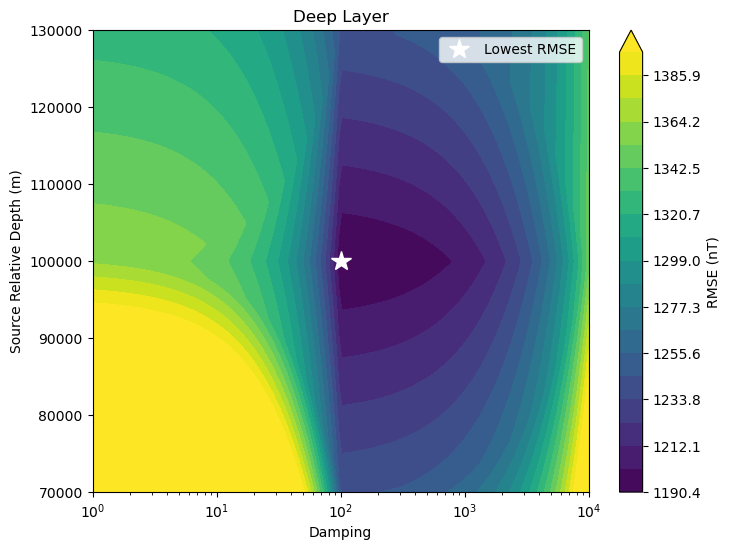

In [77]:
damping_values_deep = np.array(damping_deep)
depth_values_deep = np.array(source_depth_deep)
score_values_deep = np.array(scores_deep)

best_deep = np.argmin(score_values_deep)
best_damping_deep = damping_values_deep[best_deep]
best_depth_deep = depth_values_deep[best_deep]
best_rmse_deep = score_values_deep[best_deep]
best_params_deep = parameter_sets_deep[best_deep]
print("Best parameters:", best_params_deep)
print(f"Best RMSE: {best_rmse_deep:.3f} nT")

x_deep = np.logspace(np.log10(damping_values_deep.min()), np.log10(damping_values_deep.max()), 200)
y_deep = np.linspace(depth_values_deep.min(), depth_values_deep.max(), 200)
X_deep, Y_deep = np.meshgrid(x_deep, y_deep)
Z_deep = griddata(
    (damping_values_deep, depth_values_deep),
    score_values_deep,
    (X_deep, Y_deep),
    method='linear',
)

plt.figure(figsize=(8, 6))
levels_deep = np.linspace(
    Z_deep.min(),
    np.nanpercentile(score_values_deep, 80),
    20,
)
c = plt.contourf(
    X_deep,
    Y_deep,
    Z_deep,
    levels=levels_deep,
    cmap="viridis",
    extend='max',
)
plt.plot(
    best_damping_deep,
    best_depth_deep,
    '*',
    color='white',
    markersize=15,
    label='Lowest RMSE'
)
plt.xscale('log')
plt.xlabel('Damping')
plt.ylabel('Source Relative Depth (m)')
plt.colorbar(c, label='RMSE (nT)')
plt.legend()
plt.title("Deep Layer")
plt.show()

Run the inversion of the deep equivalent sources with the values obtained with the cross-validation.

In [78]:
%%time
eqs_deep = sph.EquivalentSourcesMagGeod(**parameter_sets_deep[best])

eqs_deep.fit(blocked_deep_equivalent_sources, inclination, declination, magnetic_anomaly_reduced)

save_fit_results(eqs_deep, filename="eqs_deep_fit_001")

CPU times: user 52.4 s, sys: 2.64 s, total: 55.1 s

Wall time: 10.4 s

In [79]:
eqs_deep_loaded = sph.EquivalentSourcesMagGeod(**parameter_sets_deep[best])

eqs_deep_loaded = load_fit_results(eqs_deep_loaded, filename="eqs_deep_fit_001")

predicted_deep = hm.total_field_anomaly(
    eqs_deep_loaded.predict(coordinates),
    inclination,
    declination,
)

residuals_deep = mag - predicted_deep 

predicted_blocked_deep = hm.total_field_anomaly(
    eqs_deep_loaded.predict(blocked_deep_equivalent_sources),
    inclination,
    declination,
)

## Cropping Region to Accelerate Cross-Validation

To improve performance, a smaller region is cropped for the shallower layer, which significantly speeds up the cross-validation process.

In [80]:
region_croped = (-54, -50, -18, -16)

cv = bd.inside((coordinates[0], coordinates[1]), region_croped)

lon_cv = coordinates[0][cv]
lat_cv = coordinates[1][cv]
height_cv = coordinates[2][cv]
mag_cv = mag[cv]
residuals_deep_cv = residuals_deep[cv]

coordinates_cv = (lon_cv, lat_cv, height_cv)
print(coordinates_cv[0].size)

12100

Create the grid.

In [ ]:
grid_spacing = deg_to_km(1)
window_size = 1.6

grid_coord = bd.grid_coordinates((-56.8, -46.5, -25, -14), spacing= grid_spacing, non_dimensional_coords=500)

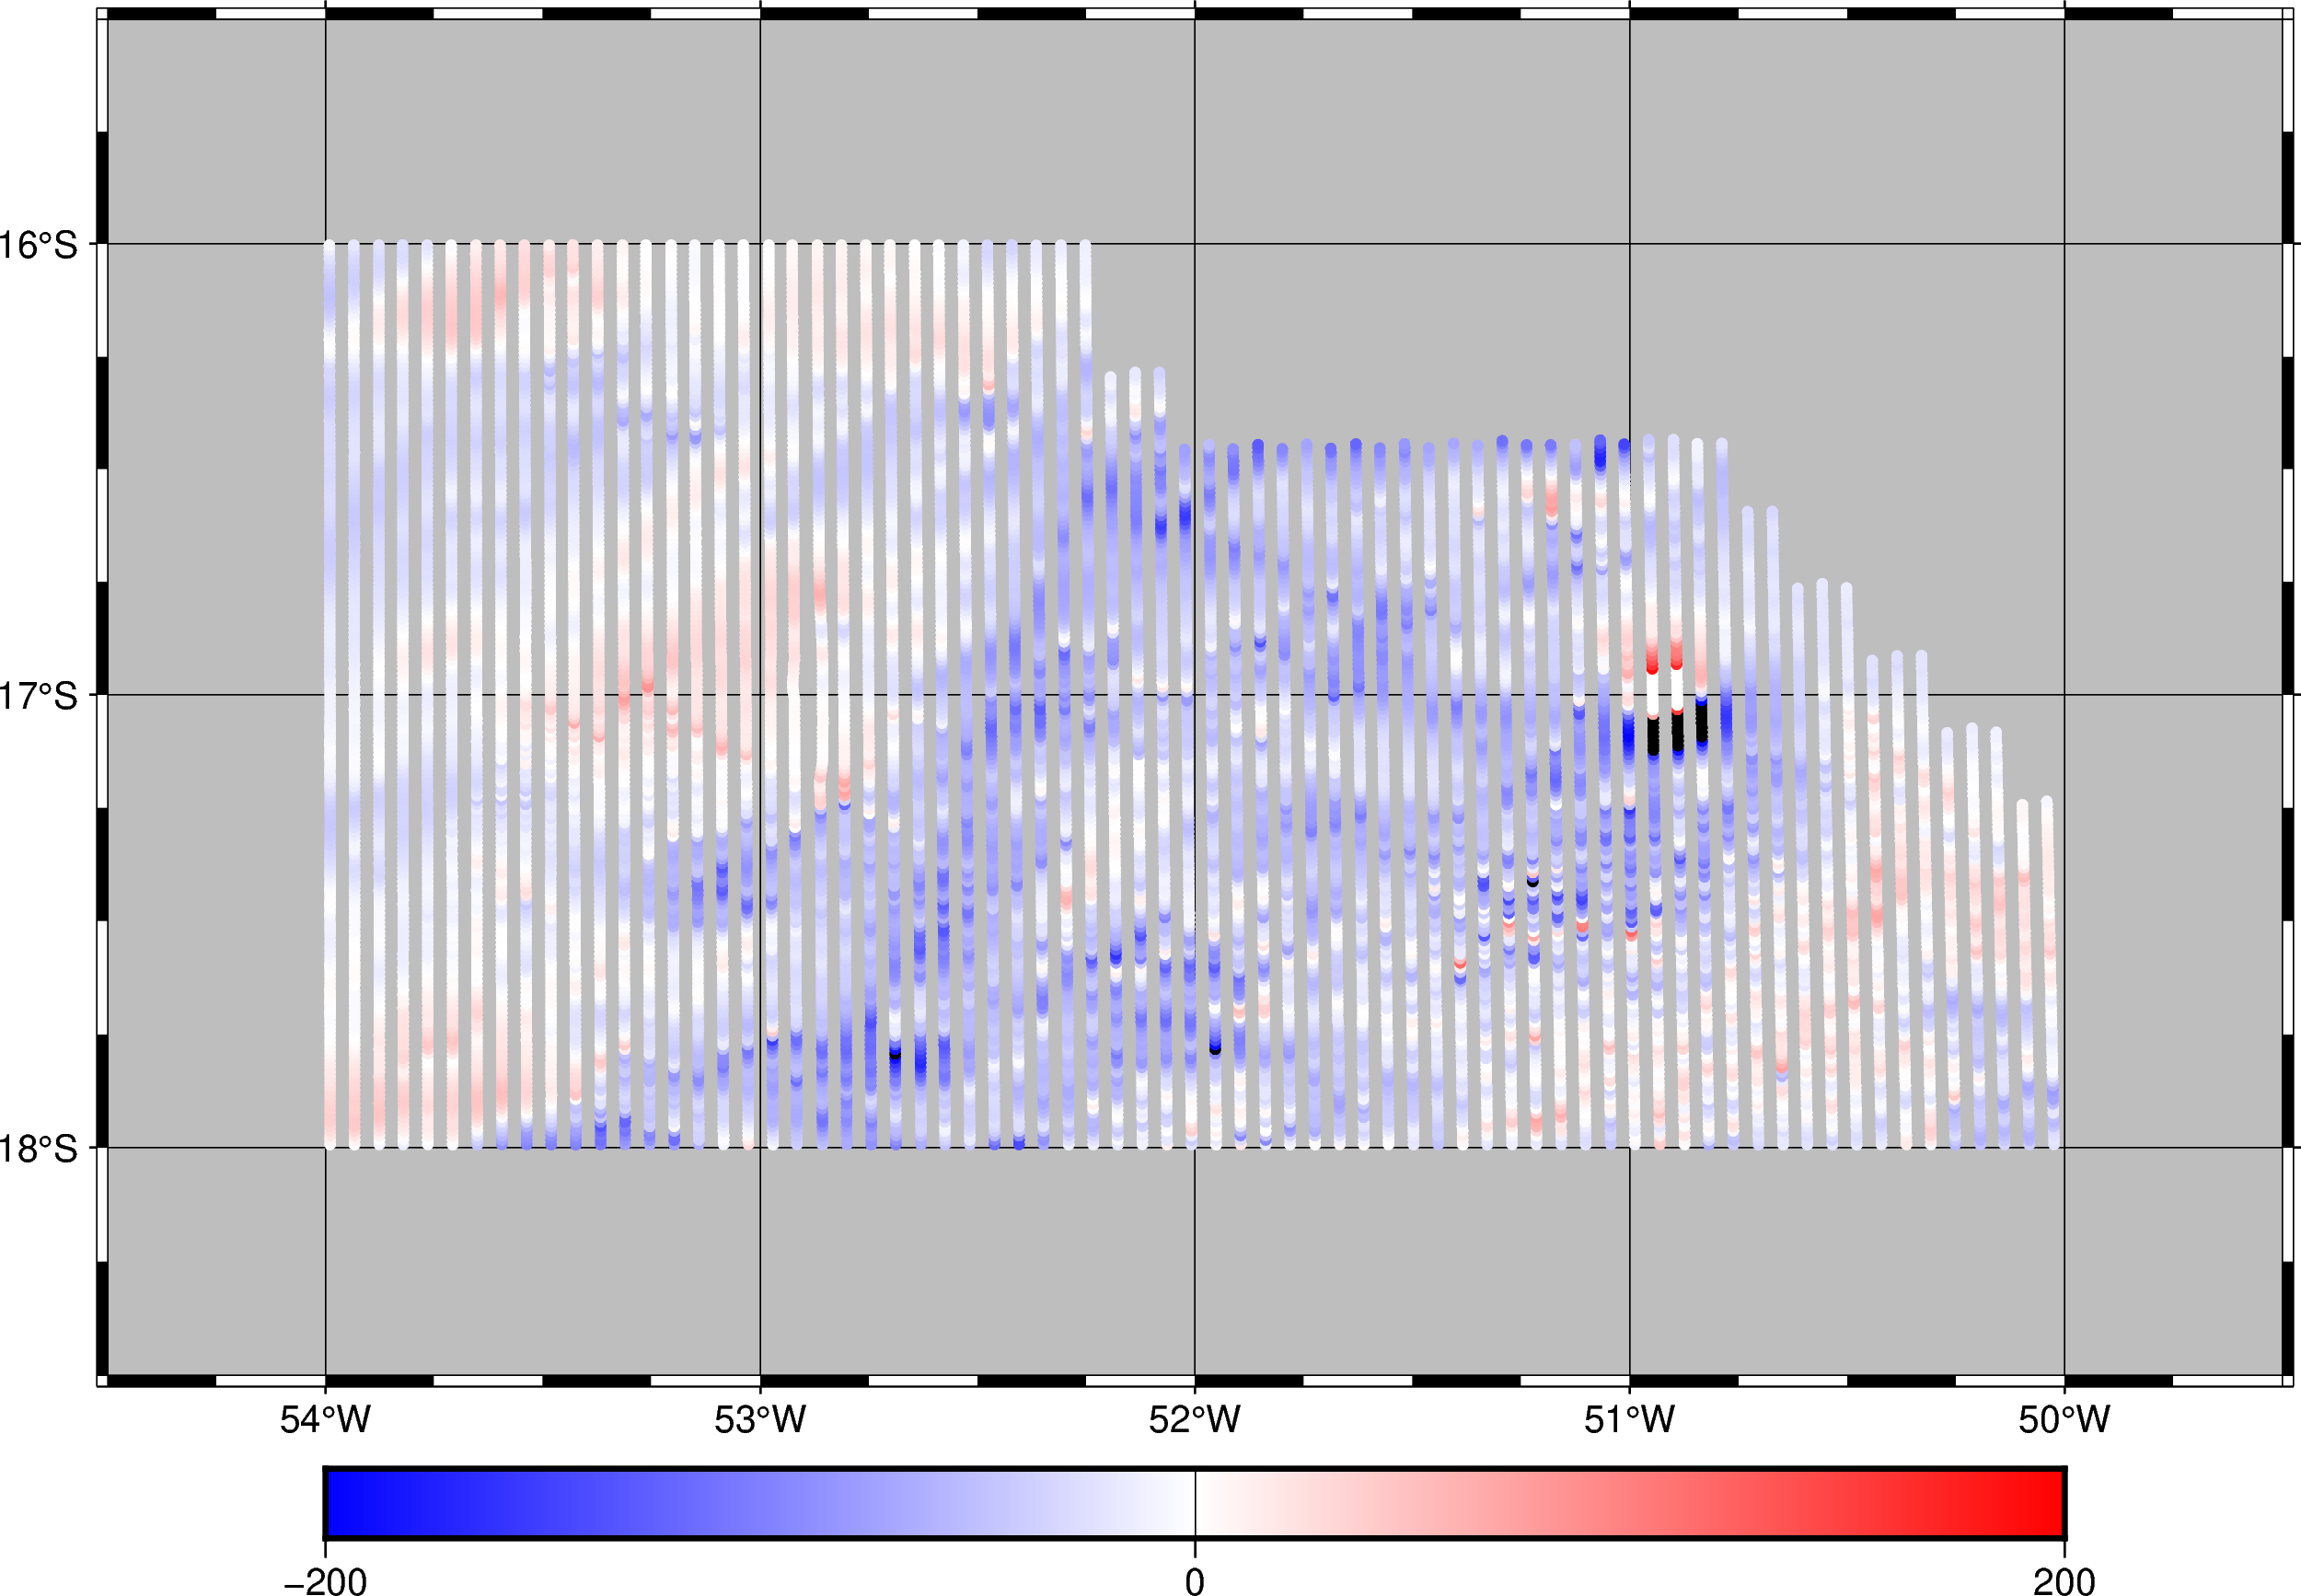

In [82]:
fig = pygmt.Figure()

fig.coast(
    region=[-54.5, -49.5, -18.5, -15.5],
    projection="M20c", 
    frame="afg",
    land="gray"
)

scale = 200 
pygmt.makecpt(cmap="polar+h", series=[-scale, scale])

fig.plot(
    x=coordinates_cv[0],
    y=coordinates_cv[1],
    fill=mag_cv,
    style="c0.1c",
    cmap=True
)

fig.colorbar(position="JBC")
fig.show(width=700)

In [83]:
dampings_shallow = [1e2,1e4, 1e6]
depths_shallow = [6e3, 9e3, 12e3] 
parameter_sets_shallow = [
    dict(damping=combo[0], depth=combo[1])
    for combo in itertools.product(dampings_shallow, depths_shallow)
] 
print("Number of combinations:", len(parameter_sets_shallow))

Number of combinations: 9

In [84]:
%%time
kfold = vd.BlockKFold(
    spacing=deg_to_km(20),
    shuffle=True,
    random_state=0,
    balance=True,
)
features = np.transpose(coordinates_cv[:2])
scores_shallow = []
damping_shallow = []
source_depth_shallow = []
for parameters in parameter_sets_shallow:    
    print(parameters)
    eqs_shallow = sph.EquivalentSourcesMagGeodGB(block_size=grid_spacing, window_size=1.5,verbose=False,**parameters)
    tmp = []
    for train, test in kfold.split(features):
        eqs_shallow.fit(
            [c[train] for c in coordinates_cv],  
            inclination,declination,
            residuals_deep_cv[train],
        )
        predicted = hm.total_field_anomaly(
            eqs_shallow.predict([c[test] for c in coordinates_cv]),
            inclination,declination,
        )
        tmp.append(np.linalg.norm(residuals_deep_cv[test] - predicted))
    scores_shallow.append(np.mean(tmp))
    damping_shallow.append(parameters['damping'])
    source_depth_shallow.append(parameters['depth'])
best = np.argmin(scores_shallow)
parameter_sets_shallow[best]

{'damping': 100.0, 'depth': 6000.0}

{'damping': 100.0, 'depth': 9000.0}

{'damping': 100.0, 'depth': 12000.0}

{'damping': 10000.0, 'depth': 6000.0}

{'damping': 10000.0, 'depth': 9000.0}

...

{'damping': 1000000.0, 'depth': 9000.0}

{'damping': 1000000.0, 'depth': 12000.0}

CPU times: user 1h 8min 47s, sys: 51.7 s, total: 1h 9min 39s

Wall time: 11min 29s

{'damping': 10000.0, 'depth': 9000.0}

Best parameters: {'damping': 10000.0, 'depth': 9000.0}

Best RMSE: 1764.514 nT

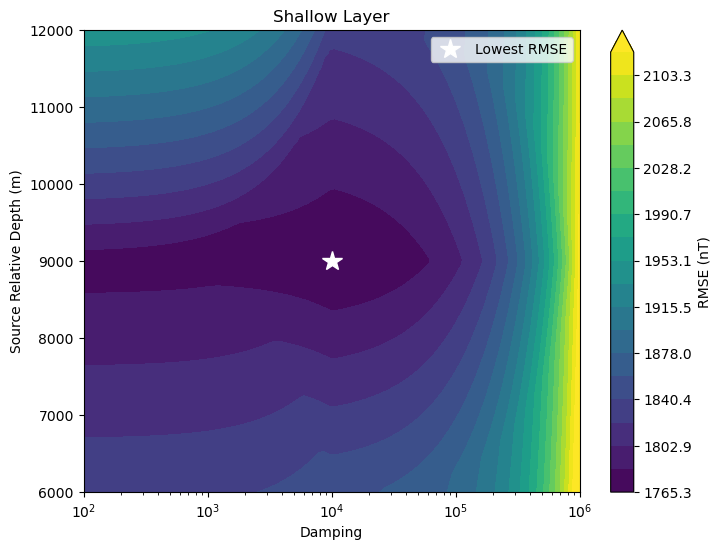

In [85]:
damping_values_shallow = np.array(damping_shallow)
depth_values_shallow = np.array(source_depth_shallow)
score_values_shallow = np.array(scores_shallow)

best_shallow = np.argmin(score_values_shallow)
best_damping_shallow = damping_values_shallow[best_shallow]
best_depth_shallow = depth_values_shallow[best_shallow]
best_rmse_shallow = score_values_shallow[best_shallow]
best_params_shallow = parameter_sets_shallow[best_shallow]
print("Best parameters:", best_params_shallow)
print(f"Best RMSE: {best_rmse_shallow:.3f} nT")

x_shallow = np.logspace(np.log10(damping_values_shallow.min()), np.log10(damping_values_shallow.max()), 100)
y_shallow = np.linspace(depth_values_shallow.min(), depth_values_shallow.max(), 100)
X_shallow, Y_shallow = np.meshgrid(x_shallow, y_shallow)

Z_shallow = griddata(
    (damping_values_shallow, depth_values_shallow),
    score_values_shallow,
    (X_shallow, Y_shallow),
    method='linear'
)
plt.figure(figsize=(8, 6))
levels_shallow = np.linspace(
    Z_shallow.min(),
    np.nanpercentile(score_values_shallow, 80),
    20,
)
c = plt.contourf(
    X_shallow,
    Y_shallow,
    Z_shallow,
    levels=levels_shallow,
    cmap="viridis",
    extend='max',
)
plt.plot(
    best_damping_shallow,
    best_depth_shallow,
    '*',
    color='white',
    markersize=15,
    label='Lowest RMSE'
)
plt.xscale('log')
plt.xlabel('Damping')
plt.ylabel('Source Relative Depth (m)')
plt.colorbar(c, label='RMSE (nT)')
plt.legend()
plt.title("Shallow Layer")
plt.show()

In [ ]:
%%time
eqs_shallow = sph.EquivalentSourcesMagGeodGB(
    block_size=grid_spacing,
    window_size=window_size,
    **parameter_sets_shallow[best]
)


eqs_shallow.fit(coordinates, inclination, declination, residuals_deep)


Working... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:22:44

CPU times: user 2h 15min 49s, sys: 1min 10s, total: 2h 17min

Wall time: 22min 45s

In [ ]:
save_fit_results(eqs_shallow, filename="eqs_shallow_fit_001")